In [1]:
from pathlib import Path
from nptdms import TdmsFile
import pandas as pd
import numpy as np
import scaleogram as scg
import matplotlib.pyplot as plt
%matplotlib inline

In [47]:
def make_subset_after(reading, sec, sampling_freq, n_cycle, rpm):
    """make subset starting at 'sec' seconds"""
    start_idx=int(sampling_freq*sec)
    num_points_in_one_period = int(sampling_freq/(rpm/60))
    return reading.iloc[start_idx:start_idx+num_points_in_one_period*n_cycle, :] 

def wavelet(data,
             rpm,
             n_flute,
             wavelet='cmor6-1.5', 
             xlim=None, ylim=None, clim=None, save=True):
        """
        X-axis: time
        Y-axis: scale - The scale correspond to the signal periodicity to which the transform is sentitive to.
        wavelets does not detect a single frequency but rather a band.
        fuzziness is proportional to the scale on y-axis
        wavelet_fun = <name><B>-<center-freq>
                    B: inversly proportional to bandwidth(smoothing) (The bandwidth parameter allow to tune the sensitivity on the period axis (Y). Or in other words the visibl amount of smoothing.)

        With logscale on Y axis, the bandwith will have the same height at all scales which may be helpful for data interpretation.
        ----------------------------------------------------------------------
        time   = np.arange(200, dtype=np.float16)-100
        data   =  np.exp(-0.5*((time)/0.2)**2)  # insert a gaussian at the center
        scales = np.arange(1,101) # scaleogram with 100 rows
        # compute ONCE the Continuous Wavelet Transform
        cwt    = scg.CWT(time, data, scales)

        # plot 1 with full range
        scg.cws(cwt)

        # plot 2 with a zoom
        scg.cws(cwt, xlim=(-50, 50), ylim=(20, 1))
    
        """

        
        expected_tooth_freq = (n_flute*rpm/60)
#         scales = np.arange(1, 10, 1)
        scales = scg.periods2scales(np.logspace(start=0, 
                                                stop=2.5,
                                                num=200) # 10**0 -- 10**2
                                   )

        cwt = scg.CWT(time = data['time'].values,
                   signal = data['data'].values-data['data'].mean(),
                   scales = scales,
                    wavelet=wavelet)

        ax=scg.cws(cwt,
                     spectrum = 'power',
                     figsize = (18, 9),
                     yscale = 'log',
                     ylabel = "Period [seconds]", 
                        xlabel = 'Time [seconds]',
                  xlim=xlim,ylim=ylim,clim=clim)
        
        text = ax.annotate("found freq", 
                           xy=(data['time'].iloc[100], 1/expected_tooth_freq), 
                           xytext=None, 
                           bbox=dict(boxstyle="round", facecolor="y", edgecolor="0.5"), 
                           arrowprops=dict(facecolor='yellow', shrink=0.05))        
        
        text = ax.annotate(f"Ref freq x2.0:{expected_tooth_freq*2}", 
                           xy=(data['time'].iloc[100], 1/(expected_tooth_freq*2)), 
                           xytext=None, 
                           bbox=dict(boxstyle="round", facecolor="y", edgecolor="0.5"), 
                           arrowprops=dict(facecolor='yellow', shrink=0.05))
        text = ax.annotate(f"Ref freq x0.5:{expected_tooth_freq*0.5}", 
                           xy=(data['time'].iloc[100], 1/(expected_tooth_freq*0.5)), 
                           xytext=None, 
                           bbox=dict(boxstyle="round", facecolor="y", edgecolor="0.5"), 
                           arrowprops=dict(facecolor='yellow', shrink=0.05)) 


        
#         ax.use_sticky_edges = False
#         p2f = lambda x:1/x
#         f2p = lambda x:1/x
#         secax = ax.secondary_yaxis('right', functions=(p2f, f2p))
#         secax.set_ylabel('Freq [Hz]')
#         pseudo_frequencies = pywt.scale2frequency(wavelet=wavelet, scale=scales)
#          for i in range(self.n_cycle):
#             ax.axvline(x=subset['time'].values[i*self.num_points_in_one_period], ymin=0.1, ymax=0.9, c='w')
        
#         # remove colorbar 
#         ax.collections[0].colorbar.remove()
        
        plt.show()
        return (ax,cwt)

In [48]:
Fs = 51200
N_FLUTE = 3
RPM = 7000
N_CYCLE = 40
START_SEC = 3

kanal_no = 1
PATH = Path(f'D:/machining/data/raw/17/accy_kanal{kanal_no}.tdms')

# read raw tdms data
reading: pd.DataFrame = TdmsFile(PATH).as_dataframe()
reading = reading.rename(
    columns={reading.columns[0]: "data"})

# add time column
reading['time'] = np.arange(reading.shape[0])*(1/Fs)

subset = make_subset_after(reading, sec=START_SEC, 
                           sampling_freq=Fs, 
                           n_cycle=N_CYCLE, rpm=RPM)

# # add ref signal: signal_freq*2 Hz
# reading['data'] += 0.01*np.sin(2*np.pi*self.expected_tooth_freq*2*self.reading['time'])

#  # add ref signal: signal_freq*0.5 Hz
# reading['data'] += 0.005*np.sin(2*np.pi*self.expected_tooth_freq*0.5*self.reading['time'])


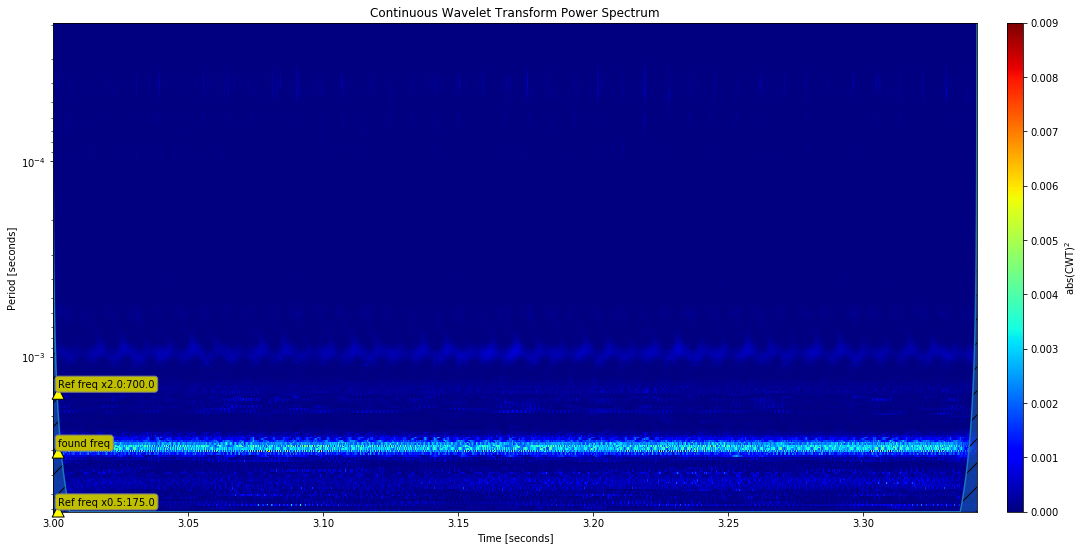

In [55]:
(ax,cwt) = wavelet(data=subset, 
        rpm=RPM,
        n_flute=N_FLUTE,
        wavelet='cmor3-1.5', xlim=None, ylim=None,clim=[0, 0.009], save=False)

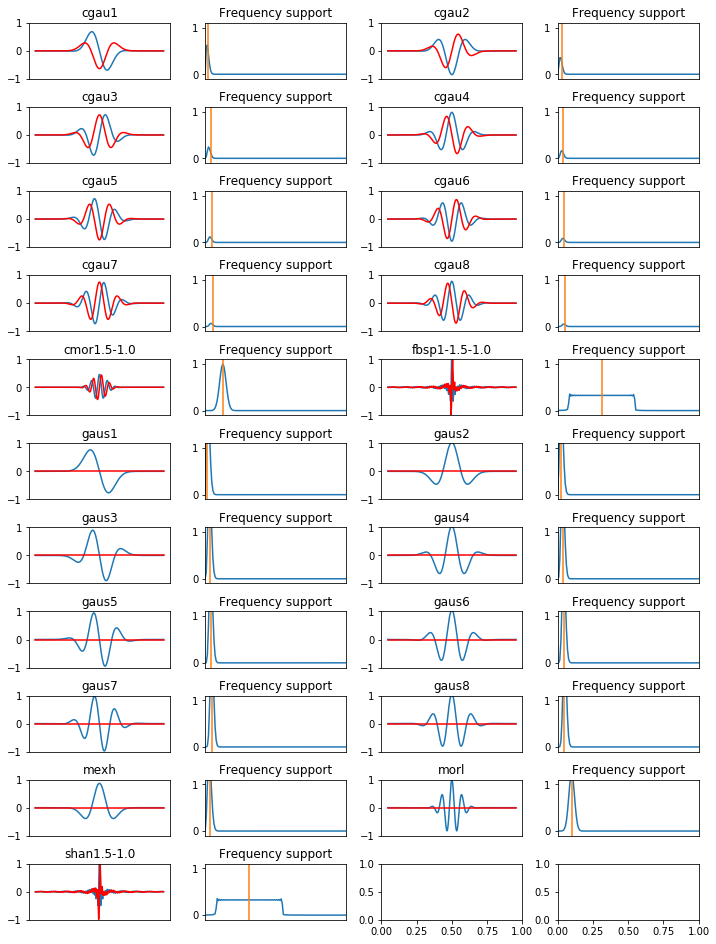

In [57]:
scg.plot_wavelets()